# Clasificación múltiple con red neuronal (PyTorch)

Clasificar **vinos en 3 cultivares** con el **dataset Wine** (UCI). Notebook ejecutable en Jupyter o cualquier IDE con Python.

- **Carga de datos:** solo **pandas** y **NumPy** (leer CSV, normalizar, split).
- **Modelo y predicciones:** red neuronal con **PyTorch** (sin Keras ni TensorFlow).

## 1. Carga y preproceso (pandas + NumPy)

Dataset Wine (UCI): 13 variables químicas del vino, 3 clases (cultivares). Solo pandas y NumPy para cargar y preparar.

In [1]:
# --- Carga y preproceso: solo pandas y NumPy (tratamiento de datos) ---
import numpy as np
import pandas as pd

# Dataset Wine (UCI): 178 muestras de vino, 3 cultivares (clases), 13 variables químicas
# (alcohol, ácido málico, ceniza, alcalinidad, magnesio, fenoles, flavonoides, etc.)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data'
# El CSV no tiene cabecera; la primera columna es la clase (1, 2 o 3), el resto son las 13 características
cols = ['class', 'Alcohol', 'Malic_acid', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
        'Flavanoids', 'Nonflavanoid', 'Proanthocyanins', 'Color', 'Hue', 'OD280', 'Proline']
df = pd.read_csv(url, header=None, names=cols)

# PyTorch CrossEntropyLoss espera índices de clase en {0, 1, ..., n_classes-1}.
# En el dataset la clase viene como 1, 2, 3; restamos 1 para obtener 0, 1, 2.
y = (df['class'].values - 1).astype(np.int64)

# Matriz de características: todas las columnas excepto 'class'. float32 para compatibilidad con PyTorch.
X = df.drop('class', axis=1).values.astype(np.float32)

# Estandarización: cada columna con media 0 y desviación típica 1. Mejora la convergencia del gradiente descendente
# y evita que variables con rango mayor (p. ej. Proline) dominen sobre las demás. 1e-8 evita división por cero.
mean, std = X.mean(axis=0), X.std(axis=0) + 1e-8
X = (X - mean) / std

# Partición entrenamiento (80 %) / test (20 %). Mezclamos con seed fija para reproducibilidad
# y para que en train y test haya muestras de las tres clases.
n = len(X)
np.random.seed(42)
idx = np.random.permutation(n)
X, y = X[idx], y[idx]
split = int(0.8 * n)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(df.head())
print('Clases:', np.unique(y))
print('Train:', X_train.shape, '| Test:', X_test.shape)

   class  Alcohol  Malic_acid   Ash  Alcalinity  Magnesium  Phenols  \
0      1    14.23        1.71  2.43        15.6        127     2.80   
1      1    13.20        1.78  2.14        11.2        100     2.65   
2      1    13.16        2.36  2.67        18.6        101     2.80   
3      1    14.37        1.95  2.50        16.8        113     3.85   
4      1    13.24        2.59  2.87        21.0        118     2.80   

   Flavanoids  Nonflavanoid  Proanthocyanins  Color   Hue  OD280  Proline  
0        3.06          0.28             2.29   5.64  1.04   3.92     1065  
1        2.76          0.26             1.28   4.38  1.05   3.40     1050  
2        3.24          0.30             2.81   5.68  1.03   3.17     1185  
3        3.49          0.24             2.18   7.80  0.86   3.45     1480  
4        2.69          0.39             1.82   4.32  1.04   2.93      735  
Clases: [0 1 2]
Train: (142, 13) | Test: (36, 13)


## 2. Red neuronal con PyTorch (modelo predictivo)

Red con capa oculta y salida softmax para 3 clases.

In [2]:
# --- Red neuronal para clasificación multiclase (PyTorch): modelo y entrenamiento ---
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_classes = 3  # Wine: 3 cultivares. La salida de la red tendrá 3 valores (uno por clase).

# La red produce "logits" (puntuaciones crudas por clase). CrossEntropyLoss aplica softmax internamente
# y luego la pérdida de entropía cruzada; no hace falta aplicar softmax manualmente en forward.
class RedMulticlase(nn.Module):
    def __init__(self, n_in, n_hidden=16, n_out=3):
        super().__init__()
        # Primera capa: n_in entradas (13 en Wine) → n_hidden neuronas ocultas (16).
        self.fc1 = nn.Linear(n_in, n_hidden)
        # Capa de salida: 16 → n_out (3). Cada neurona de salida da el logit de una clase.
        self.fc2 = nn.Linear(n_hidden, n_out)

    def forward(self, x):
        x = torch.relu(self.fc1(x))  # ReLU en la capa oculta
        # Devolvemos los logits (sin softmax). CrossEntropyLoss hace LogSoftmax + NLLLoss internamente.
        return self.fc2(x)

# Instanciar: X_train.shape[1] = 13 (número de características). n_out = 3 clases.
model = RedMulticlase(X_train.shape[1], n_out=n_classes).to(device)
# CrossEntropyLoss: entrada = logits de forma (n, n_classes), objetivo = índices de clase (tensor de enteros long).
# Combina softmax + entropía cruzada de forma numéricamente estable.
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Tensores: X en float (entradas), y en long (índices 0, 1, 2 para CrossEntropyLoss). Mismo device que el modelo.
X_tr = torch.from_numpy(X_train).to(device)
y_tr = torch.from_numpy(y_train).long().to(device)
X_te = torch.from_numpy(X_test).to(device)

epochs = 500
losses, accs = [], []
model.train()
for ep in range(epochs):
    optimizer.zero_grad()
    # logits: tensor de forma (n, 3); cada fila son las puntuaciones para las 3 clases.
    logits = model(X_tr)
    loss = criterion(logits, y_tr)  # Compara logits con índices de clase (no con one-hot)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    # argmax(dim=1): para cada muestra, índice de la clase con mayor logit (0, 1 o 2).
    pred = logits.argmax(dim=1)
    acc = (pred == y_tr).float().mean().item()
    accs.append(acc)

# Evaluación en test: sin gradientes para ahorrar memoria.
model.eval()
with torch.no_grad():
    logits = model(X_te)
    # argmax(dim=1) da la clase predicha; .cpu().numpy() para comparar con y_test (array NumPy).
    pred_test = logits.argmax(dim=1).cpu().numpy()

acc_test = (pred_test == y_test).mean()
print(f'Accuracy test: {acc_test:.4f}')
print(f'Cross-entropy final train: {losses[-1]:.4f}')

Accuracy test: 0.9722
Cross-entropy final train: 0.0003


## 3. Curvas de entrenamiento

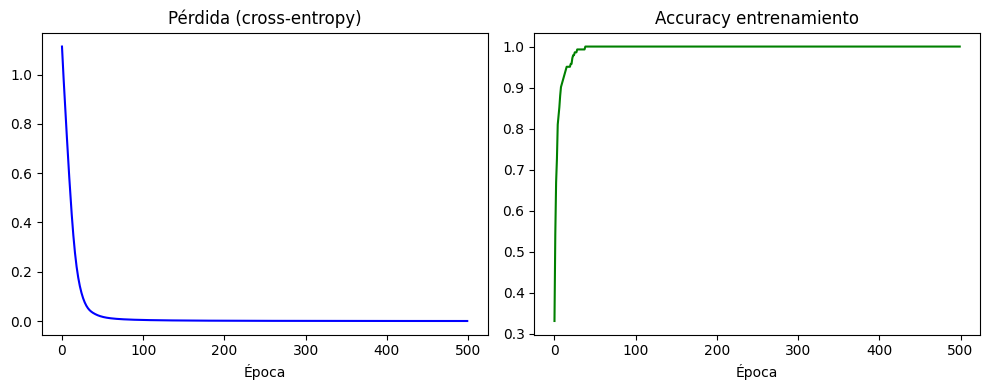

In [3]:
import matplotlib.pyplot as plt

# Curvas de entrenamiento: subplot 1 = pérdida, subplot 2 = accuracy, ambos por época.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Izquierda: cross-entropy en entrenamiento. Debe disminuir; si se estanca, el modelo puede estar convergiendo.
ax1.plot(losses, color='blue')
ax1.set_xlabel('Época')
ax1.set_title('Pérdida (cross-entropy)')

# Derecha: fracción de muestras de entrenamiento clasificadas correctamente. Suele aumentar con las épocas.
ax2.plot(accs, color='green')
ax2.set_xlabel('Época')
ax2.set_title('Accuracy entrenamiento')

plt.tight_layout()
plt.show()